## Option Data Download

In [1]:
# from data_loader.fetch_option_data import fetch_data_by_month
# fetch_data_by_month("MU", "2016-01-01", "2026-03-15")

## Bcaktesting the Wheel Strategy

In [1]:
from backtest.backtest import run_wheel_backtest
from backtest.report import WheelPerformanceReport

symbol = "SPY"

result = run_wheel_backtest(
    symbol=symbol,
    start_date="2016-01-01",
    end_date="2026-03-15",
    target_delta=0.2,
    stop_loss_multiple=1.5,
    put_exp_days=12,
    call_exp_days=0,
    initial_cash=5000,
    leverage=10,
)

report = WheelPerformanceReport(result)

In [2]:
report.summary_table()

,Value
Metric,
Symbol,SPY
Start Date,2016-01-04
End Date,2026-03-13
Initial Cash,"$5,000.00"
Ending Equity,"$23,027.00"
Net Profit,"$18,027.00"
Cash Interest Earned,"$3,010.50"
Total Return,360.54%
CAGR,16.17%


In [3]:
report.trade_breakdown_table()

,legs,total_premium,avg_premium,avg_roi,avg_iv,avg_abs_delta,avg_moneyness,avg_days_held
type,,,,,,,,
put,385,"$64,428.50",$167.35,0.12%,19.91%,0.20,-2.99%,8.31


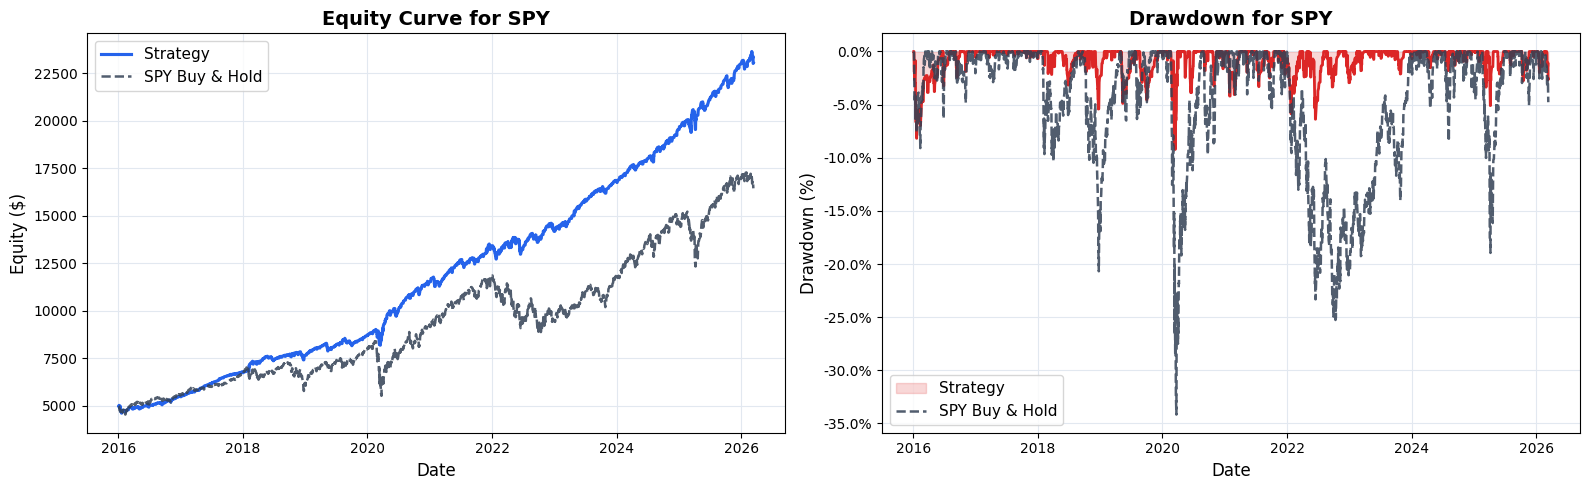

In [4]:
_ = report.plot_equity_and_drawdown()

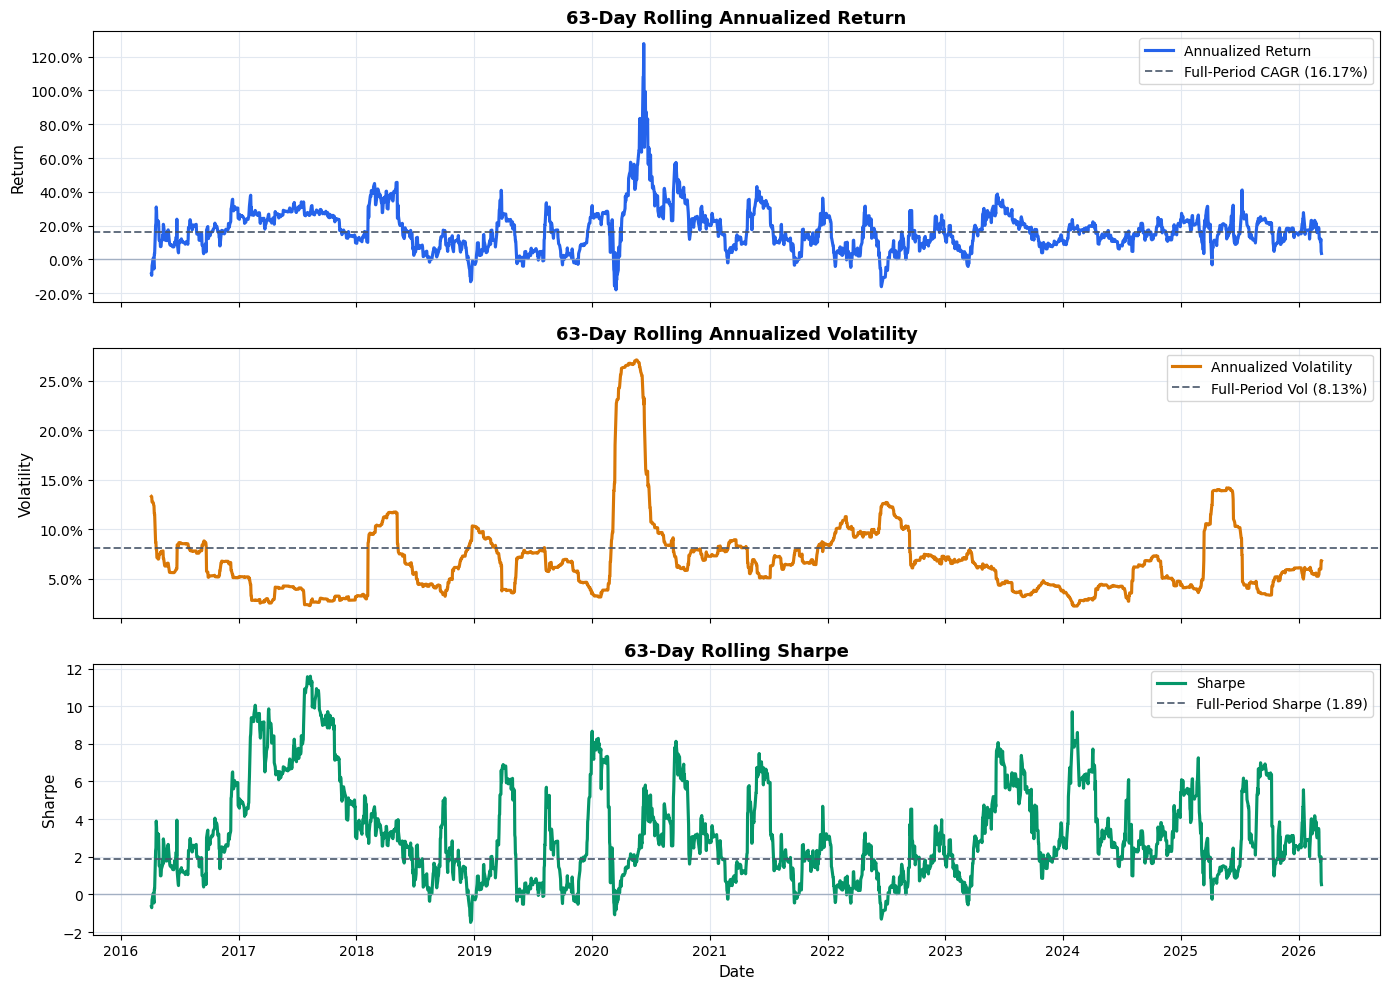

In [ ]:
_ = report.plot_rolling_metrics(252)

In [6]:
from IPython.display import HTML, display

def display_long_df(df, max_height=400, max_width='100%'):
    html = (
        f"<div style='max-height:{max_height}px; overflow:auto; width:{max_width}; padding:5px;'>"
        f"{df.to_html(escape=False, index=False)}"
        f"</div>"
    )
    display(HTML(html))

display_long_df(result.trades)

date,side,type,strike,expiration,premium_per_share,premium,delta,leverage_ratio,moneyness,iv,outcome,days_held,ROI%,cash_flow,nav,exec_spot,spot,buyback_price_per_share,stop_trigger_price_per_share,stop_open_price_per_share,liquidation_cost
2016-01-04,short,put,194.5,2016-01-22,1.285,128.500000,-0.224716,3.890000,-3.426018,0.215812,cut_loss,2,-0.336761,-65.500000,4934.570924,201.400,199.050,1.9400,2.10,1.94,NaN
2016-01-07,short,put,185.0,2016-01-22,1.115,111.500000,-0.188225,3.749034,-4.540764,0.266795,cut_loss,6,-0.301351,-55.750000,4878.997187,193.800,188.750,1.6725,1.71,0.36,NaN
2016-01-14,short,put,184.0,2016-01-29,1.190,119.000000,-0.203552,3.771235,-4.141704,0.261087,cut_loss,1,-0.989130,-182.000000,4697.078790,191.950,187.810,3.0100,3.76,3.01,NaN
2016-01-19,short,put,178.0,2016-02-05,1.390,139.000000,-0.195778,3.789556,-5.288922,0.304752,cut_loss,1,-0.438202,-78.000000,4619.162395,187.940,186.050,2.1700,3.59,2.17,NaN
2016-01-21,short,put,177.0,2016-02-05,1.350,135.000000,-0.195678,3.831827,-5.154860,0.317877,expired,15,0.762712,135.000000,4754.773726,186.620,188.150,NaN,NaN,NaN,NaN
2016-02-08,short,put,176.5,2016-02-26,1.285,128.500000,-0.194357,3.712019,-5.030939,0.279949,cut_loss,3,-0.427762,-75.500000,4679.471645,185.850,183.090,2.0400,2.50,2.04,NaN
2016-02-12,short,put,179.0,2016-02-26,1.140,114.000000,-0.206171,3.825179,-3.969957,0.261892,expired,14,0.636872,114.000000,4793.978205,186.400,194.900,NaN,NaN,NaN,NaN
2016-02-29,short,put,185.0,2016-03-18,1.215,121.500000,-0.204496,3.858965,-4.466822,0.238883,expired,18,0.656757,121.500000,4916.261144,193.650,204.310,NaN,NaN,NaN,NaN
2016-03-21,short,put,199.5,2016-04-08,0.725,72.500000,-0.199201,4.057919,-2.568861,0.140980,cut_loss,3,-0.403509,-80.500000,4835.963998,204.760,203.310,1.5300,1.53,1.53,NaN
2016-03-28,short,put,197.5,2016-04-15,0.815,81.500000,-0.200648,4.083944,-2.833809,0.157963,expired,18,0.412658,81.500000,4918.032155,203.260,207.960,NaN,NaN,NaN,NaN


## Grid Search for Hyperparameter Optimization

In [ ]:
import pandas as pd
from backtest.grid_search import run_grid_search

grid_results_spy = run_grid_search(
    symbol=symbol,
    start_date="2016-01-01",
    end_date="2026-03-15",
    initial_cash=8_000,
    leverage=10,
    max_workers=5,
)

Starting grid search: 245 cases, max_workers=5
Symbol=SPY, period=2016-01-01 to 2026-03-15


In [ ]:
# grid_results = pd.read_csv("data/grid_search/grid_results_spy.csv")
filtered_results = grid_results_spy[grid_results_spy["cagr"] > 0.1]
display_long_df(filtered_results[["case", "cagr", "sharpe", "max_drawdown"]].sort_values(by=["sharpe", "cagr"], ascending=False))

In [ ]:
grid_results_qqq = run_grid_search(
    symbol="QQQ",
    start_date="2016-01-01",
    end_date="2026-03-15",
    initial_cash=5_000,
    leverage=10,
    max_workers=5,
)

In [ ]:
# grid_results_qqq = pd.read_csv("data/grid_search/grid_results_qqq.csv")
filtered_results = grid_results_qqq[grid_results_qqq["cagr"] > 0.1]
display_long_df(filtered_results[["case", "cagr", "sharpe", "max_drawdown"]].sort_values(by=["sharpe", "cagr"], ascending=False))

In [ ]:
from pathlib import Path

data_dir = Path("data/grid_search")
data_dir.mkdir(parents=True, exist_ok=True)

grid_results_spy.to_csv(data_dir / "grid_results_spy.csv", index=False)
grid_results_qqq.to_csv(data_dir / "grid_results_qqq.csv", index=False)